# 51 - 顔検出の基礎: InsightFace セットアップと動作確認

顔認識実験シリーズの第1弾。InsightFace を使って画像から顔を検出し、
各属性（バウンディングボックス、ランドマーク、年齢・性別、512次元Embedding）を確認する。

## 入力
- `data/images.duckdb` (image_catalog テーブル)

## 出力
- 顔検出の動作確認と各カテゴリの特性理解
- カテゴリ別の顔数分布統計

In [1]:
import time
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from insightface.app import FaceAnalysis
from PIL import Image
from tqdm.notebook import tqdm

2026-02-14 16:12:48.177393922 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 設定

In [2]:
# DuckDBファイルのパス
DB_PATH = Path("../data/images.duckdb")

# InsightFace モデル名
MODEL_NAME = "buffalo_l"

# 検出サイズ（デフォルト）
DET_SIZE = (640, 640)

## InsightFace モデルの初期化

InsightFace の `buffalo_l` モデルパック:
- **顔検出**: SCRFD (Single-stage face detector)
- **顔Embedding**: ArcFace (512次元)
- **属性推定**: 年齢・性別
- **ランドマーク**: 5点 (両目、鼻、両口角)

In [3]:
print("InsightFace モデルを読み込み中...")
app = FaceAnalysis(name=MODEL_NAME, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=DET_SIZE)
print(f"モデル: {MODEL_NAME}")
print(f"検出サイズ: {DET_SIZE}")
print(f"使用プロバイダー: {[p for p in ['CUDAExecutionProvider', 'CPUExecutionProvider']]}")

InsightFace モデルを読み込み中...
download_path: /home/terapyon/.insightface/models/buffalo_l


  0%|          | 0/281857 [00:00<?, ?KB/s]

  0%|          | 1134/281857 [00:00<00:24, 11229.20KB/s]

  1%|          | 2286/281857 [00:00<00:24, 11329.69KB/s]

  1%|          | 3424/281857 [00:00<00:24, 11352.10KB/s]

...

 99%|█████████▉| 280092/281857 [00:29<00:00, 11026.20KB/s]

100%|█████████▉| 281341/281857 [00:29<00:00, 11434.16KB/s]

100%|██████████| 281857/281857 [00:29<00:00, 9519.88KB/s] 

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
モデル: buffalo_l
検出サイズ: (640, 640)
使用プロバ

## 画像カタログの読み込み

In [4]:
conn = duckdb.connect(str(DB_PATH), read_only=True)

# カテゴリ別の画像数
categories = conn.execute("""
    SELECT category, COUNT(*) as count
    FROM image_catalog
    GROUP BY category
    ORDER BY count DESC
""").fetchdf()

print("カテゴリ別画像数:")
display(categories)

# 全画像を取得
all_images = conn.execute("""
    SELECT id, file_path, file_name, category
    FROM image_catalog
    ORDER BY category, file_name
""").fetchdf()

print(f"\n総画像数: {len(all_images)}")

カテゴリ別画像数:


,category,count
0,EuroPython2025,129
1,PyConJP2025,77
2,PyConJP2025-PreCampHiroshima,57
3,KashiwaVillagePark2026,56
4,TokyoNight202505,49
5,terada,10



総画像数: 378


## 各カテゴリのサンプル画像で顔検出

まず各カテゴリから1枚ずつサンプルを選んで、顔検出の結果を詳しく確認する。

In [5]:
def detect_faces(app, image_path: str) -> list:
    """画像から顔を検出する"""
    img = cv2.imread(image_path)
    if img is None:
        return []
    faces = app.get(img)
    return faces


def draw_faces(image_path: str, faces: list, max_width: int = 800) -> np.ndarray:
    """顔検出結果をアノテーション付きで描画する"""
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for face in faces:
        # バウンディングボックス
        bbox = face.bbox.astype(int)
        cv2.rectangle(img_rgb, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 3)

        # 5点ランドマーク
        if face.kps is not None:
            for kp in face.kps.astype(int):
                cv2.circle(img_rgb, (kp[0], kp[1]), 5, (255, 0, 0), -1)

        # ラベル（年齢・性別・スコア）
        gender = "M" if face.gender == 1 else "F"
        label = f"{gender} age:{face.age} score:{face.det_score:.2f}"
        cv2.putText(
            img_rgb, label,
            (bbox[0], bbox[1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2
        )

    # リサイズ（表示用）
    h, w = img_rgb.shape[:2]
    if w > max_width:
        scale = max_width / w
        img_rgb = cv2.resize(img_rgb, (max_width, int(h * scale)))

    return img_rgb

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


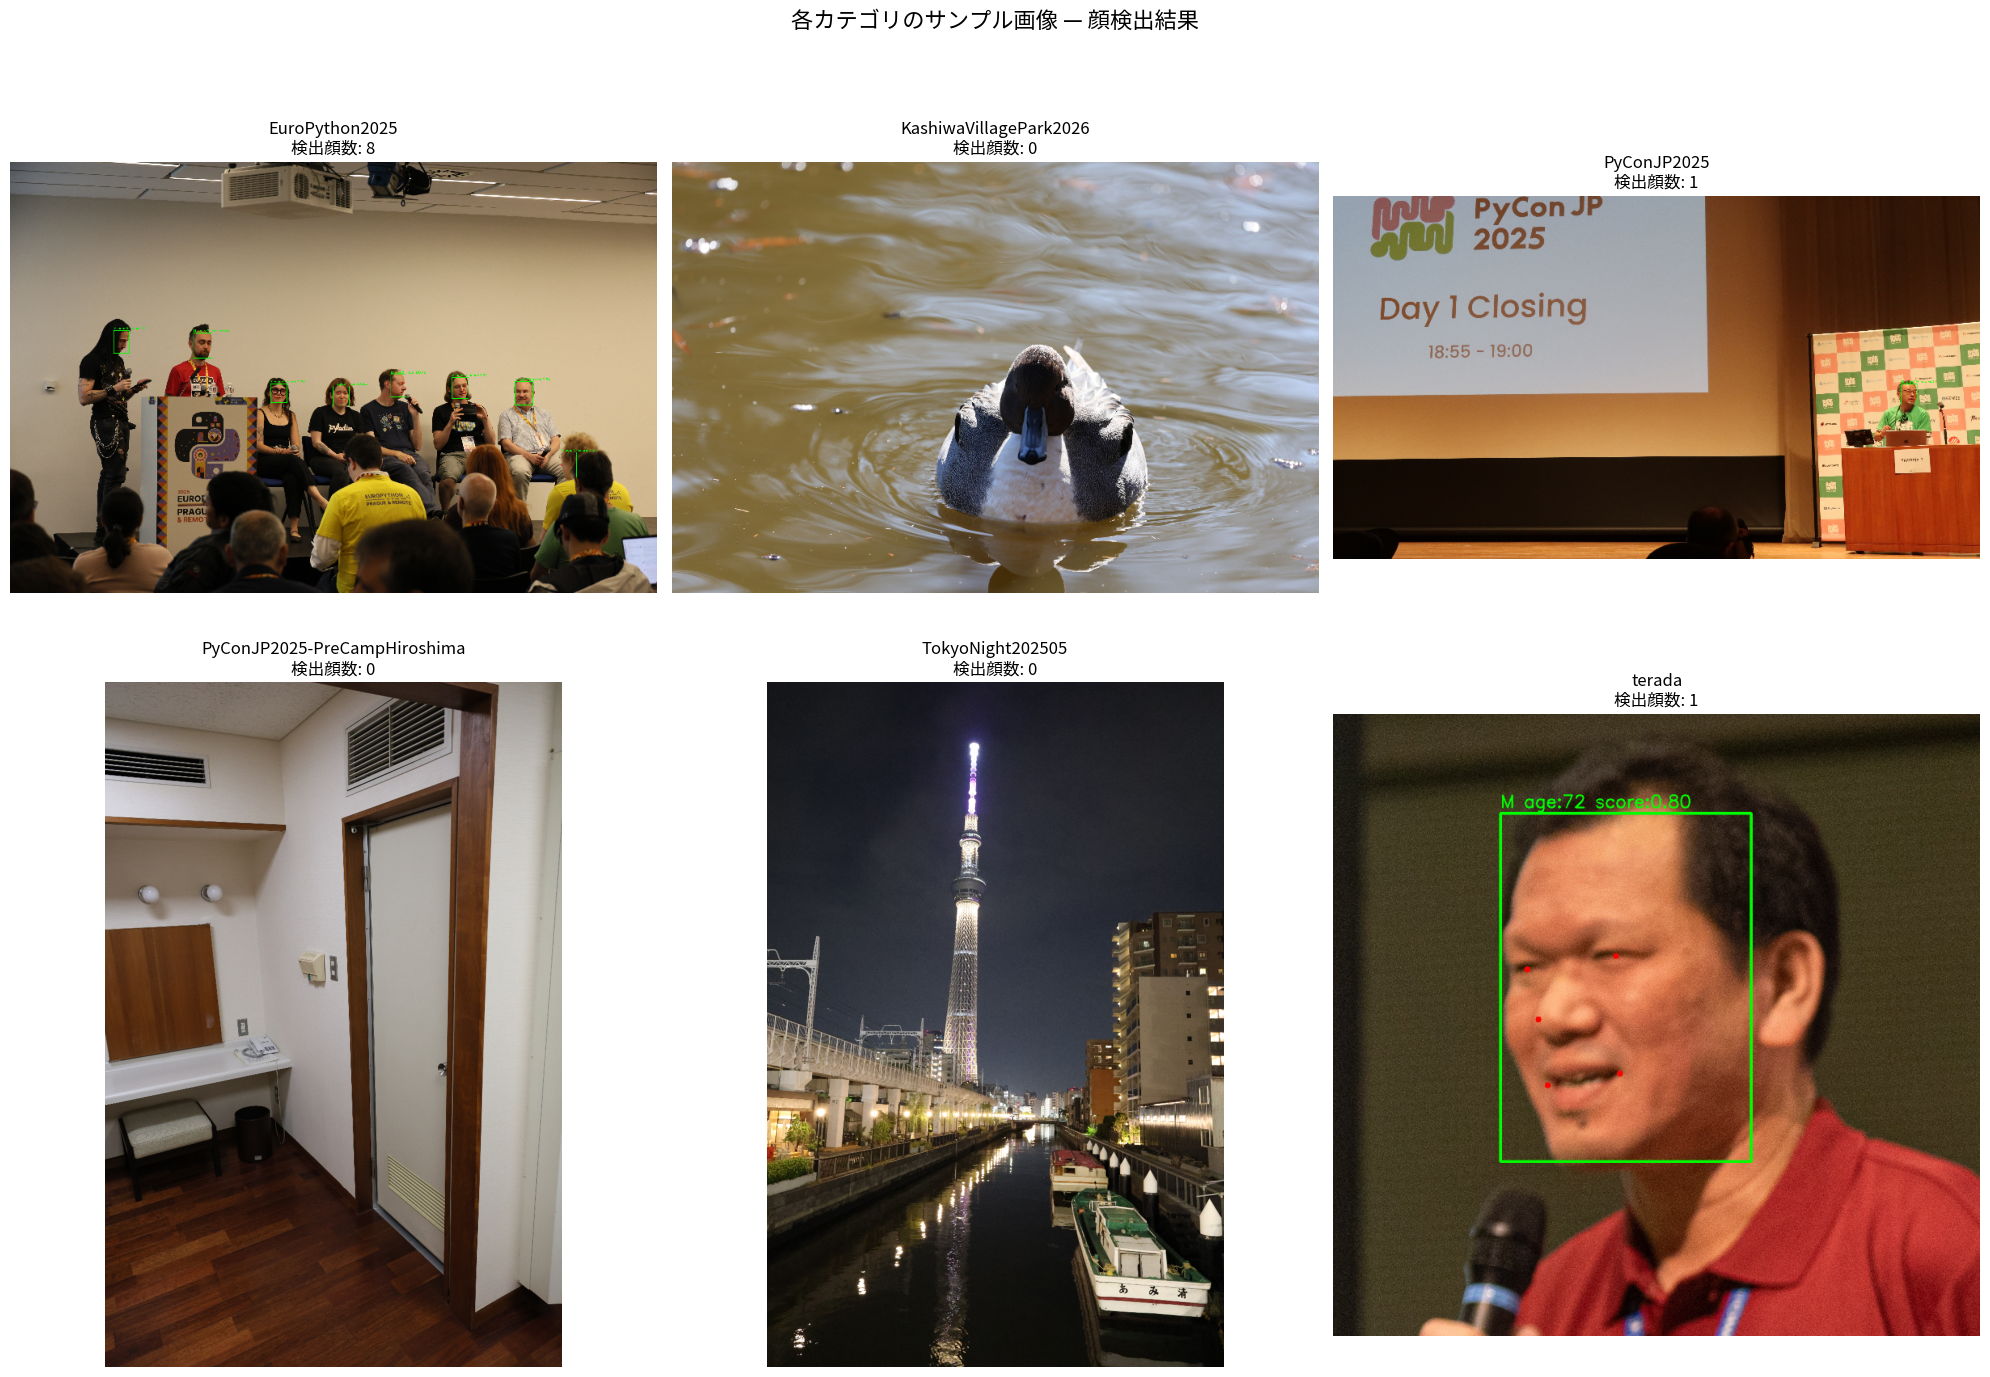


サンプル検出結果:


,category,file_name,num_faces
0,EuroPython2025,2025-07-17 22.14.14.jpg,8
1,KashiwaVillagePark2026,2026-01-03 13.29.55.jpg,0
2,PyConJP2025,2025-09-26 18.56.20.jpg,1
3,PyConJP2025-PreCampHiroshima,2025-06-07 16.21.05.jpg,0
4,TokyoNight202505,2025-04-27 20.34.59.jpg,0
5,terada,terada-pyconjp2019.jpg,1


In [6]:
# 各カテゴリから1枚ずつサンプル
category_list = all_images["category"].unique()

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

sample_results = []

for idx, cat in enumerate(sorted(category_list)):
    # カテゴリの中央あたりの画像を選択
    cat_images = all_images[all_images["category"] == cat]
    sample = cat_images.iloc[len(cat_images) // 2]

    # 顔検出
    faces = detect_faces(app, sample["file_path"])
    annotated = draw_faces(sample["file_path"], faces)

    # 結果を記録
    sample_results.append({
        "category": cat,
        "file_name": sample["file_name"],
        "num_faces": len(faces),
    })

    # 描画
    axes[idx].imshow(annotated)
    axes[idx].set_title(f"{cat}\n検出顔数: {len(faces)}", fontsize=12)
    axes[idx].axis("off")

plt.suptitle("各カテゴリのサンプル画像 — 顔検出結果", fontsize=16)
plt.tight_layout()
plt.show()

print("\nサンプル検出結果:")
display(pd.DataFrame(sample_results))

## Face オブジェクトの属性を詳しく確認

terada カテゴリの画像で、Face オブジェクトの各属性を詳細に調べる。

In [7]:
# terada カテゴリの最初の画像で詳細確認
terada_images = all_images[all_images["category"] == "terada"]
sample_path = terada_images.iloc[0]["file_path"]
print(f"サンプル画像: {terada_images.iloc[0]['file_name']}")

faces = detect_faces(app, sample_path)
print(f"検出顔数: {len(faces)}\n")

for i, face in enumerate(faces):
    print(f"--- Face {i} ---")
    print(f"  bbox (x1,y1,x2,y2): {face.bbox}")
    print(f"  det_score: {face.det_score:.4f}")
    print(f"  kps (5点ランドマーク): shape={face.kps.shape}")
    print(f"    左目:  {face.kps[0]}")
    print(f"    右目:  {face.kps[1]}")
    print(f"    鼻:    {face.kps[2]}")
    print(f"    左口角: {face.kps[3]}")
    print(f"    右口角: {face.kps[4]}")
    print(f"  age: {face.age}")
    print(f"  gender: {'M' if face.gender == 1 else 'F'} (raw={face.gender})")
    print(f"  normed_embedding: shape={face.normed_embedding.shape}, dtype={face.normed_embedding.dtype}")
    print(f"  embedding norm: {np.linalg.norm(face.normed_embedding):.6f}")
    print(f"  embedding 先頭5要素: {face.normed_embedding[:5]}")
    print()

サンプル画像: 202203証明写真オリジナル.jpg
検出顔数: 1

--- Face 0 ---
  bbox (x1,y1,x2,y2): [ 519.79767  428.00394 1512.628   1794.2422 ]
  det_score: 0.9000
  kps (5点ランドマーク): shape=(5, 2)
    左目:  [797.2384  989.84204]
    右目:  [1239.2693   993.89496]
    鼻:    [1021.288  1237.5299]
    左口角: [ 824.5624 1449.465 ]
    右口角: [1211.6394 1452.4279]
  age: 49
  gender: M (raw=1)
  normed_embedding: shape=(512,), dtype=float32
  embedding norm: 1.000000
  embedding 先頭5要素: [0.06102335 0.05209024 0.0394646  0.00013581 0.00971663]



/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


## det_size パラメータの比較

検出サイズを変えると、小さい顔の検出感度と処理速度が変わる。
カンファレンス写真（群衆）で比較する。

In [8]:
# カンファレンス写真（群衆が写っていそうなもの）を選択
conference_images = all_images[all_images["category"].isin(["EuroPython2025", "PyConJP2025"])]
# 複数枚で比較
test_images = conference_images.sample(n=min(5, len(conference_images)), random_state=42)

det_sizes = [(320, 320), (640, 640)]
det_size_results = []

for det_size in det_sizes:
    print(f"\ndet_size={det_size} でテスト中...")
    app_test = FaceAnalysis(name=MODEL_NAME, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    app_test.prepare(ctx_id=0, det_size=det_size)

    for _, row in test_images.iterrows():
        start = time.time()
        faces = detect_faces(app_test, row["file_path"])
        elapsed = time.time() - start

        det_size_results.append({
            "det_size": f"{det_size[0]}x{det_size[1]}",
            "file_name": row["file_name"],
            "num_faces": len(faces),
            "time_sec": elapsed,
        })

df_det = pd.DataFrame(det_size_results)
print("\ndet_size 比較結果:")
display(df_det.pivot_table(index="file_name", columns="det_size", values=["num_faces", "time_sec"]))


det_size=(320, 320) でテスト中...


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}


find model: /home/terapyon/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/2d106det.o

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}


find model: /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)



det_size=(640, 640) でテスト中...


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)



det_size 比較結果:


num_faces          time_sec          
det_size                  320x320 640x640   320x320   640x640
file_name                                                    
2025-07-16 16.06.02.jpg       1.0     0.0  2.135327  0.149035
2025-07-16 17.07.33.jpg       0.0     0.0  0.194026  0.169226
2025-07-17 23.50.35.jpg       1.0     1.0  0.208977  2.071785
2025-07-18 04.05.43.jpg       0.0     0.0  0.120260  0.079167
2025-09-28 18.24.31.jpg       0.0     0.0  0.118196  0.076915

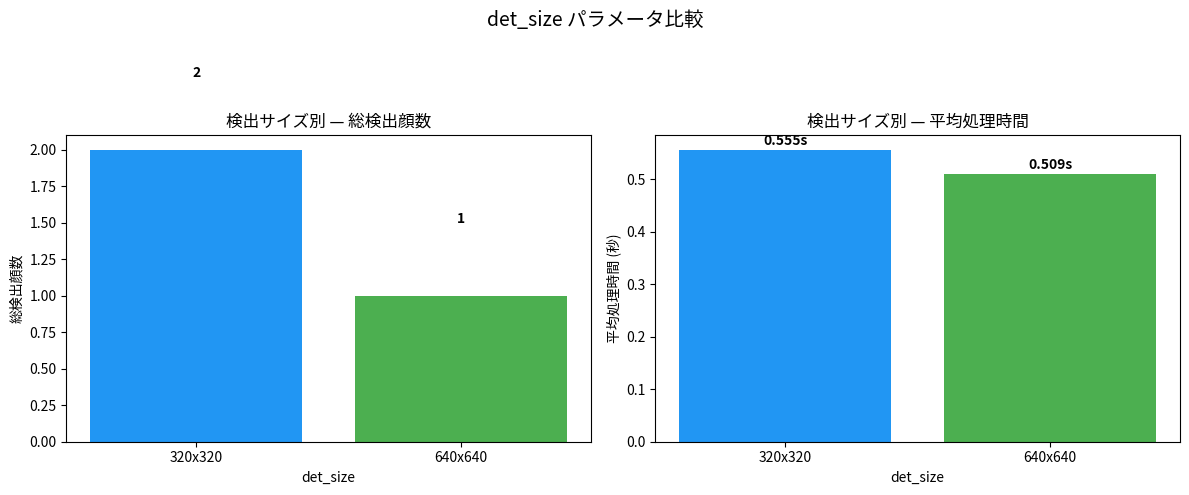

In [9]:
# det_size 比較の可視化
summary = df_det.groupby("det_size").agg(
    avg_faces=("num_faces", "mean"),
    total_faces=("num_faces", "sum"),
    avg_time=("time_sec", "mean"),
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(summary["det_size"], summary["total_faces"], color=["#2196F3", "#4CAF50"])
ax1.set_title("検出サイズ別 — 総検出顔数")
ax1.set_xlabel("det_size")
ax1.set_ylabel("総検出顔数")
for i, v in enumerate(summary["total_faces"]):
    ax1.text(i, v + 0.5, str(int(v)), ha="center", fontweight="bold")

ax2.bar(summary["det_size"], summary["avg_time"], color=["#2196F3", "#4CAF50"])
ax2.set_title("検出サイズ別 — 平均処理時間")
ax2.set_xlabel("det_size")
ax2.set_ylabel("平均処理時間 (秒)")
for i, v in enumerate(summary["avg_time"]):
    ax2.text(i, v + 0.01, f"{v:.3f}s", ha="center", fontweight="bold")

plt.suptitle("det_size パラメータ比較", fontsize=14)
plt.tight_layout()
plt.show()

## 全378枚の顔検出

全画像に対して顔検出を実行し、カテゴリ別の統計を取得する。

In [10]:
# 全画像で顔検出
all_detection_results = []

for _, row in tqdm(all_images.iterrows(), total=len(all_images), desc="顔検出中"):
    start = time.time()
    faces = detect_faces(app, row["file_path"])
    elapsed = time.time() - start

    all_detection_results.append({
        "id": row["id"],
        "file_name": row["file_name"],
        "category": row["category"],
        "num_faces": len(faces),
        "max_score": max((f.det_score for f in faces), default=0.0),
        "time_sec": elapsed,
    })

df_all = pd.DataFrame(all_detection_results)
print(f"\n処理完了: {len(df_all)} 画像")
print(f"総検出顔数: {df_all['num_faces'].sum()}")
print(f"平均処理時間: {df_all['time_sec'].mean():.3f} 秒/枚")

顔検出中:   0%|          | 0/378 [00:00<?, ?it/s]

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)



処理完了: 378 画像
総検出顔数: 691
平均処理時間: 0.126 秒/枚


In [11]:
# カテゴリ別統計
cat_stats = df_all.groupby("category").agg(
    image_count=("id", "count"),
    total_faces=("num_faces", "sum"),
    avg_faces=("num_faces", "mean"),
    max_faces=("num_faces", "max"),
    images_with_faces=("num_faces", lambda x: (x > 0).sum()),
    avg_time=("time_sec", "mean"),
).reset_index()

cat_stats["face_ratio"] = (cat_stats["images_with_faces"] / cat_stats["image_count"] * 100).round(1)

print("カテゴリ別統計:")
display(cat_stats)

カテゴリ別統計:


,category,image_count,total_faces,avg_faces,max_faces,images_with_faces,avg_time,face_ratio
0,EuroPython2025,129,345,2.674419,50,97,0.133902,75.2
1,KashiwaVillagePark2026,56,1,0.017857,1,1,0.138628,1.8
2,PyConJP2025,77,294,3.818182,18,57,0.092699,74.0
3,PyConJP2025-PreCampHiroshima,57,37,0.649123,6,14,0.147632,24.6
4,TokyoNight202505,49,4,0.081633,2,3,0.141441,6.1
5,terada,10,10,1.000000,1,10,0.015625,100.0


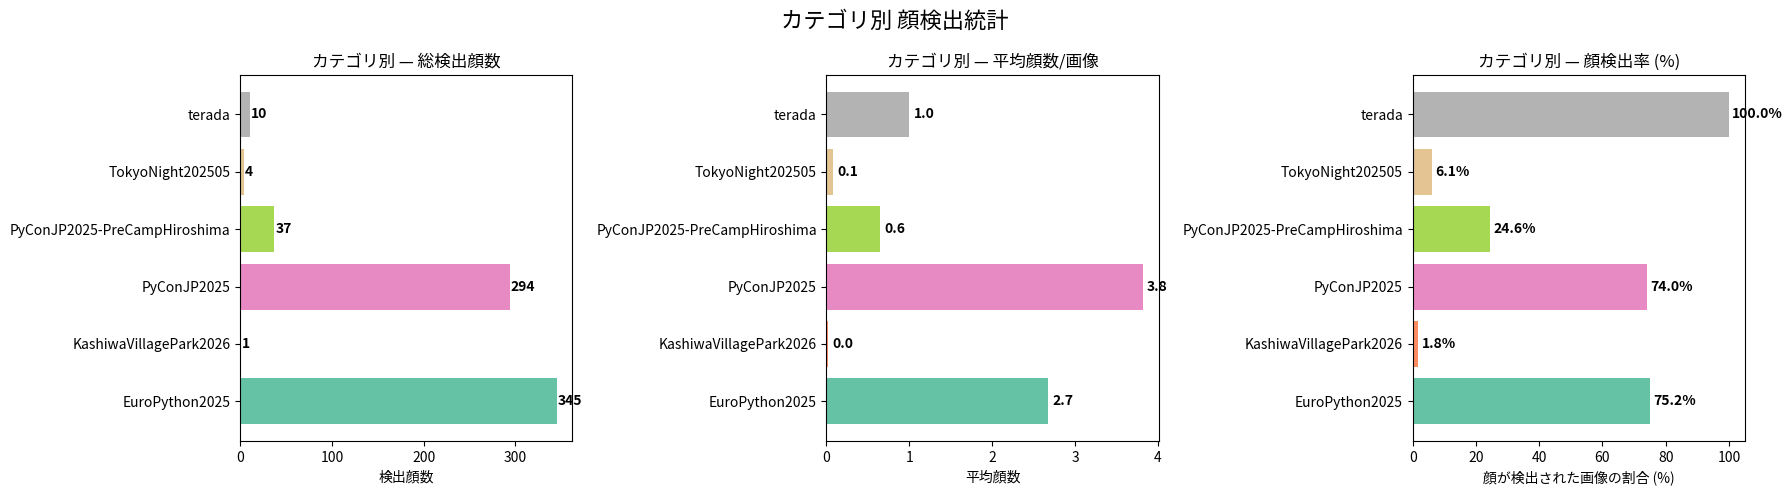

In [12]:
# カテゴリ別の顔数分布（バーチャート）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. カテゴリ別総検出顔数
colors = plt.cm.Set2(np.linspace(0, 1, len(cat_stats)))
bars = axes[0].barh(cat_stats["category"], cat_stats["total_faces"], color=colors)
axes[0].set_title("カテゴリ別 — 総検出顔数")
axes[0].set_xlabel("検出顔数")
for bar, val in zip(bars, cat_stats["total_faces"]):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(int(val)), va="center", fontweight="bold")

# 2. カテゴリ別平均顔数/画像
bars = axes[1].barh(cat_stats["category"], cat_stats["avg_faces"], color=colors)
axes[1].set_title("カテゴリ別 — 平均顔数/画像")
axes[1].set_xlabel("平均顔数")
for bar, val in zip(bars, cat_stats["avg_faces"]):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}", va="center", fontweight="bold")

# 3. 顔検出率
bars = axes[2].barh(cat_stats["category"], cat_stats["face_ratio"], color=colors)
axes[2].set_title("カテゴリ別 — 顔検出率 (%)")
axes[2].set_xlabel("顔が検出された画像の割合 (%)")
axes[2].set_xlim(0, 105)
for bar, val in zip(bars, cat_stats["face_ratio"]):
    axes[2].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontweight="bold")

plt.suptitle("カテゴリ別 顔検出統計", fontsize=16)
plt.tight_layout()
plt.show()

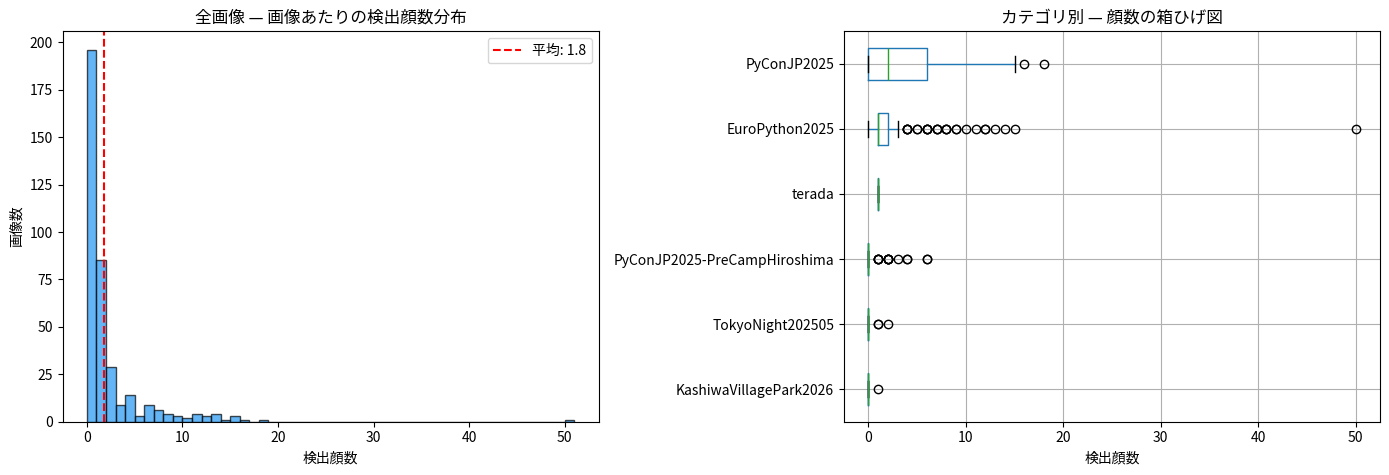

顔数の統計:
  最小: 0
  最大: 50
  平均: 1.8
  中央値: 0
  顔なし画像: 196 / 378


In [13]:
# 画像あたりの顔数ヒストグラム
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 全体の分布
max_faces = df_all["num_faces"].max()
bins = range(0, max_faces + 2)
ax1.hist(df_all["num_faces"], bins=bins, edgecolor="black", alpha=0.7, color="#2196F3")
ax1.set_title("全画像 — 画像あたりの検出顔数分布")
ax1.set_xlabel("検出顔数")
ax1.set_ylabel("画像数")
ax1.axvline(df_all["num_faces"].mean(), color="red", linestyle="--", label=f"平均: {df_all['num_faces'].mean():.1f}")
ax1.legend()

# カテゴリ別の分布（箱ひげ図）
cat_order = cat_stats.sort_values("avg_faces", ascending=True)["category"].tolist()
df_all_sorted = df_all.copy()
df_all_sorted["category"] = pd.Categorical(df_all_sorted["category"], categories=cat_order, ordered=True)
df_all_sorted.boxplot(column="num_faces", by="category", ax=ax2, vert=False)
ax2.set_title("カテゴリ別 — 顔数の箱ひげ図")
ax2.set_xlabel("検出顔数")
ax2.set_ylabel("")
plt.suptitle("")

plt.tight_layout()
plt.show()

# 統計サマリー
print(f"顔数の統計:")
print(f"  最小: {df_all['num_faces'].min()}")
print(f"  最大: {df_all['num_faces'].max()}")
print(f"  平均: {df_all['num_faces'].mean():.1f}")
print(f"  中央値: {df_all['num_faces'].median():.0f}")
print(f"  顔なし画像: {(df_all['num_faces'] == 0).sum()} / {len(df_all)}")

## terada カテゴリの全画像で顔検出

顔検索のクエリとして使う terada (10枚のポートレート) の検出結果を確認する。

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


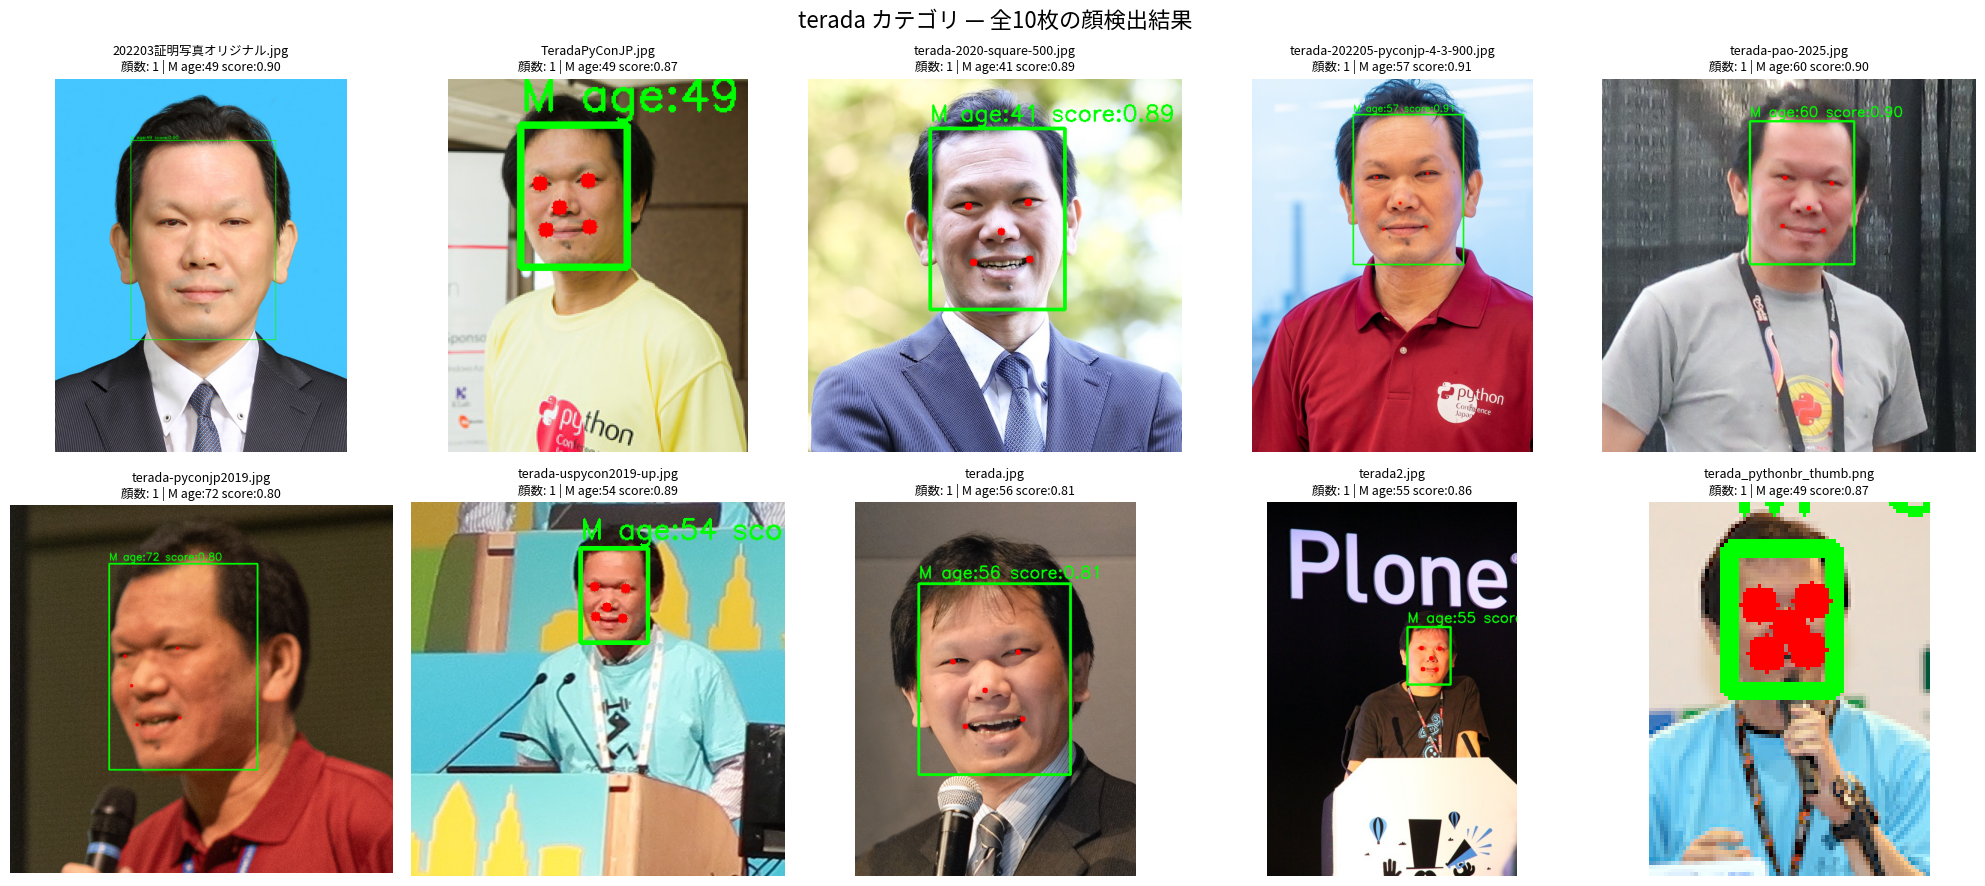

In [14]:
terada_images = all_images[all_images["category"] == "terada"]

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for idx, (_, row) in enumerate(terada_images.iterrows()):
    faces = detect_faces(app, row["file_path"])
    annotated = draw_faces(row["file_path"], faces)

    axes[idx].imshow(annotated)
    title = f"{row['file_name']}\n顔数: {len(faces)}"
    if faces:
        gender = "M" if faces[0].gender == 1 else "F"
        title += f" | {gender} age:{faces[0].age} score:{faces[0].det_score:.2f}"
    axes[idx].set_title(title, fontsize=9)
    axes[idx].axis("off")

plt.suptitle("terada カテゴリ — 全10枚の顔検出結果", fontsize=16)
plt.tight_layout()
plt.show()

## カンファレンス写真の多人数検出例

複数人が写っている画像で、各顔が個別に検出されることを確認する。

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


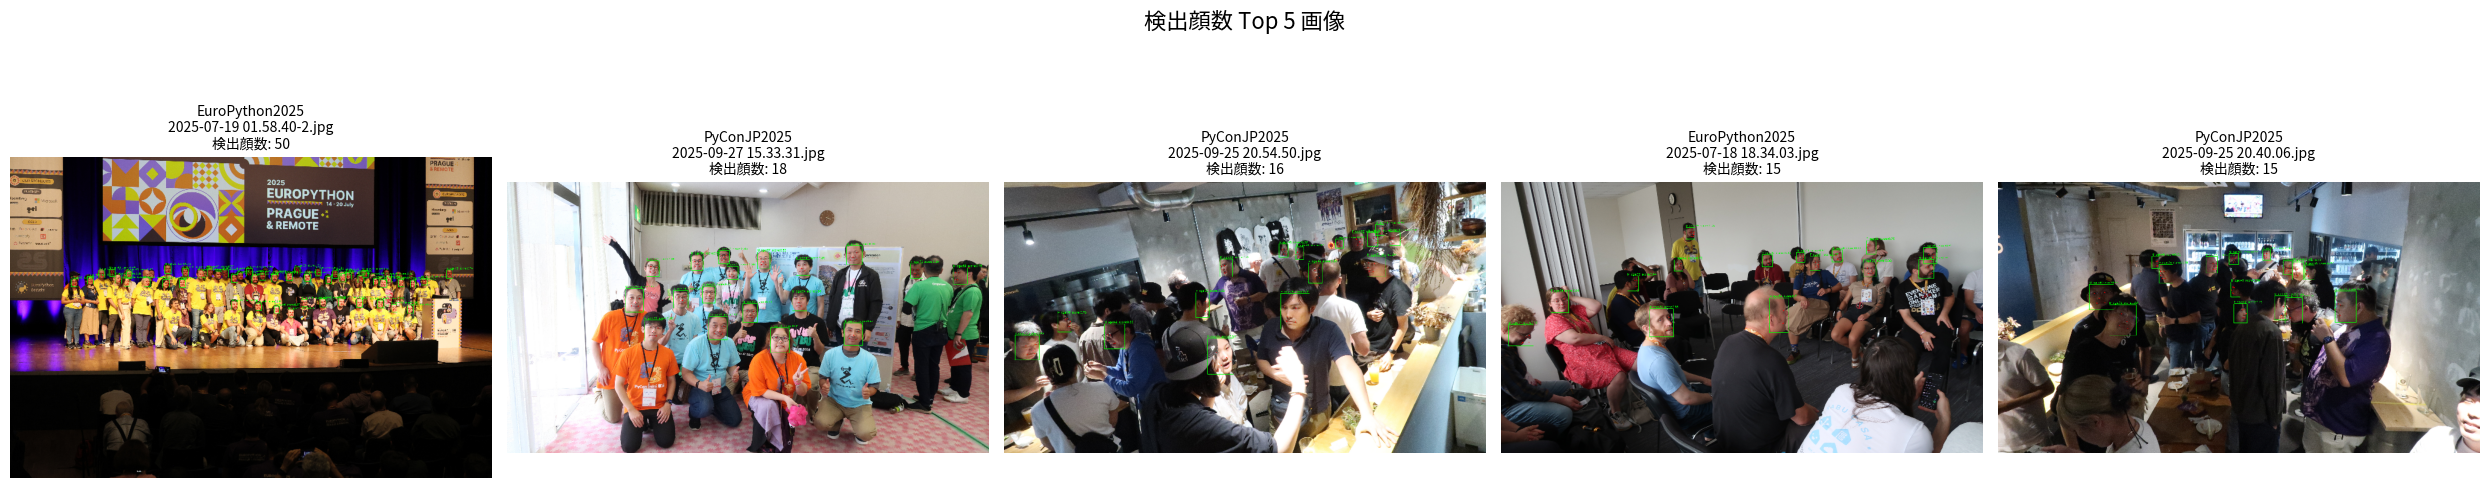

In [15]:
# 顔数が多い画像 Top 5 を表示
top_faces = df_all.nlargest(5, "num_faces")

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for idx, (_, row) in enumerate(top_faces.iterrows()):
    file_path = all_images[all_images["id"] == row["id"]]["file_path"].values[0]
    faces = detect_faces(app, file_path)
    annotated = draw_faces(file_path, faces)

    axes[idx].imshow(annotated)
    axes[idx].set_title(f"{row['category']}\n{row['file_name']}\n検出顔数: {row['num_faces']}", fontsize=10)
    axes[idx].axis("off")

plt.suptitle("検出顔数 Top 5 画像", fontsize=16)
plt.tight_layout()
plt.show()

## 顔クロップの確認

検出された顔のバウンディングボックスから切り出した顔画像を確認する。
これが後続のノートブックで Embedding の入力となる。

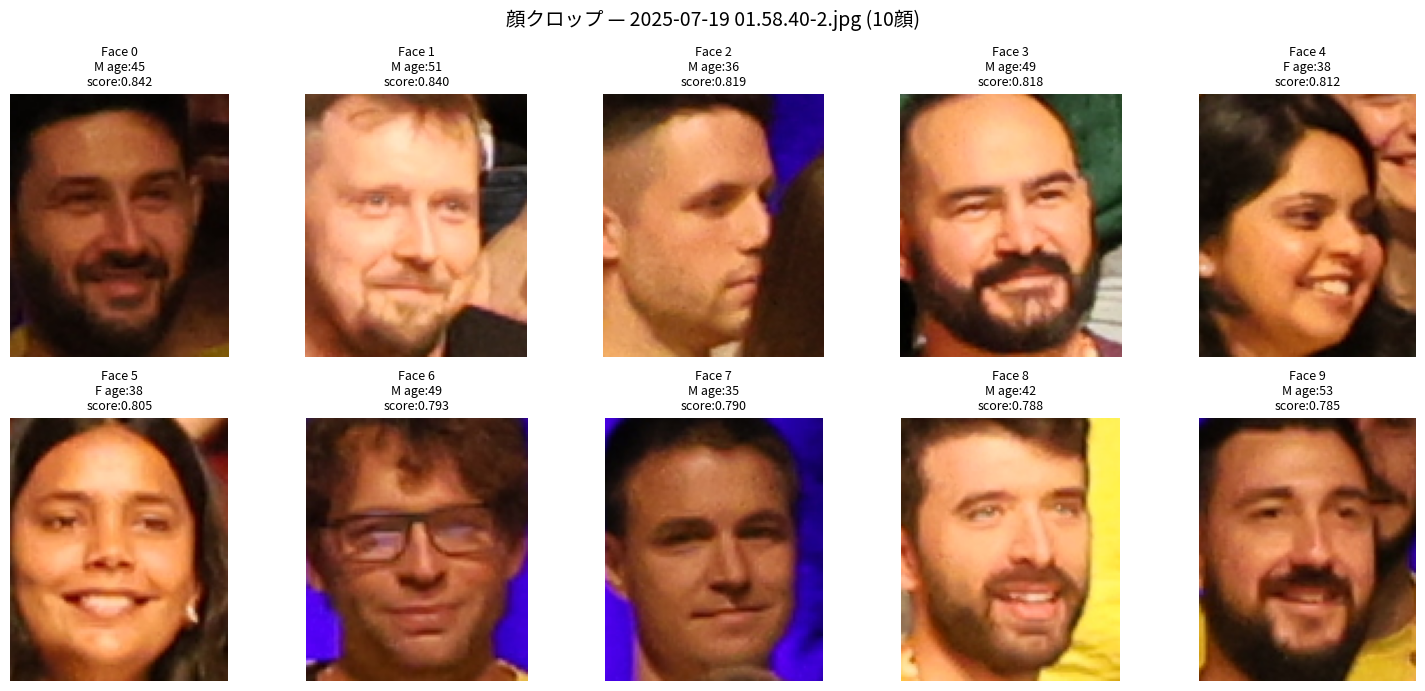

In [16]:
# 顔数が多い画像の1枚目から、個別の顔をクロップして表示
top_row = top_faces.iloc[0]
file_path = all_images[all_images["id"] == top_row["id"]]["file_path"].values[0]
faces = detect_faces(app, file_path)

img_pil = Image.open(file_path).convert("RGB")

n_faces = min(len(faces), 10)  # 最大10人分
cols = min(n_faces, 5)
rows = (n_faces + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3.5 * rows))
if rows == 1 and cols == 1:
    axes = np.array([axes])
axes = np.array(axes).flatten()

for i in range(n_faces):
    face = faces[i]
    bbox = face.bbox.astype(int)
    # パディング付きクロップ
    x1 = max(0, bbox[0] - 10)
    y1 = max(0, bbox[1] - 10)
    x2 = min(img_pil.width, bbox[2] + 10)
    y2 = min(img_pil.height, bbox[3] + 10)
    face_crop = img_pil.crop((x1, y1, x2, y2))

    gender = "M" if face.gender == 1 else "F"
    axes[i].imshow(face_crop)
    axes[i].set_title(f"Face {i}\n{gender} age:{face.age}\nscore:{face.det_score:.3f}", fontsize=9)
    axes[i].axis("off")

# 余ったaxesを非表示
for i in range(n_faces, len(axes)):
    axes[i].axis("off")

plt.suptitle(f"顔クロップ — {top_row['file_name']} ({n_faces}顔)", fontsize=14)
plt.tight_layout()
plt.show()

## Embedding の基本特性確認

ArcFace の 512次元 Embedding の特性を確認する。

terada Embedding: shape=(10, 512)
Embedding ノルム (正規化済みなので ≈ 1.0): [1.         1.         0.99999994 1.         0.99999994 1.
 1.         0.99999994 1.         1.        ]


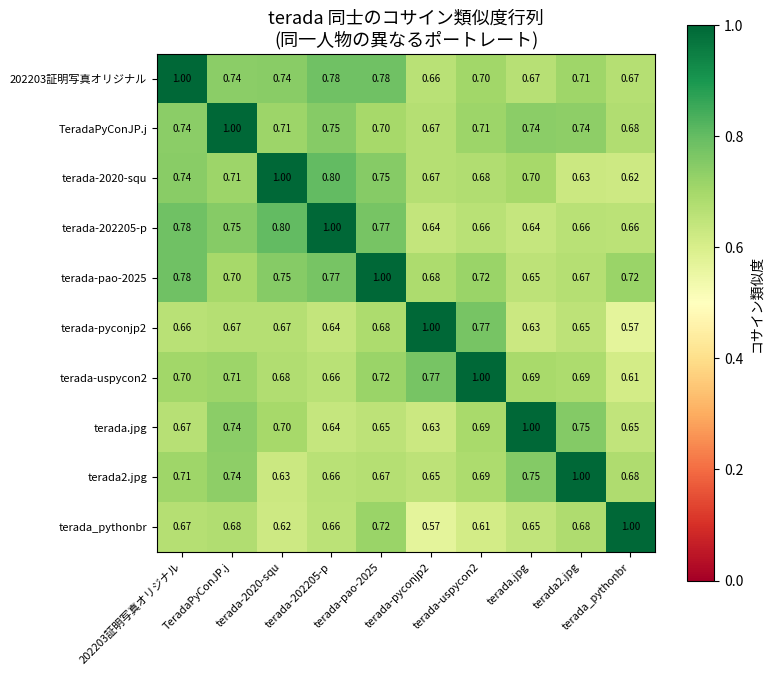


terada 同士のコサイン類似度 (対角除く):
  平均: 0.6924
  最小: 0.5665
  最大: 0.8009
  標準偏差: 0.0503


In [17]:
# terada の全画像から顔 Embedding を取得
terada_embeddings = []
terada_labels = []

for _, row in terada_images.iterrows():
    faces = detect_faces(app, row["file_path"])
    if faces:
        # 最大スコアの顔を選択
        best_face = max(faces, key=lambda f: f.det_score)
        terada_embeddings.append(best_face.normed_embedding)
        terada_labels.append(row["file_name"])

terada_embs = np.array(terada_embeddings)
print(f"terada Embedding: shape={terada_embs.shape}")
print(f"Embedding ノルム (正規化済みなので ≈ 1.0): {np.linalg.norm(terada_embs, axis=1)}")

# terada 同士のコサイン類似度
cos_sim = terada_embs @ terada_embs.T

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cos_sim, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(terada_labels)))
ax.set_yticks(range(len(terada_labels)))
ax.set_xticklabels([l[:15] for l in terada_labels], rotation=45, ha="right", fontsize=8)
ax.set_yticklabels([l[:15] for l in terada_labels], fontsize=8)

# 値をセルに表示
for i in range(len(terada_labels)):
    for j in range(len(terada_labels)):
        ax.text(j, i, f"{cos_sim[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax, label="コサイン類似度")
ax.set_title("terada 同士のコサイン類似度行列\n(同一人物の異なるポートレート)", fontsize=13)
plt.tight_layout()
plt.show()

# 対角要素以外の統計
mask = ~np.eye(len(terada_labels), dtype=bool)
off_diag = cos_sim[mask]
print(f"\nterada 同士のコサイン類似度 (対角除く):")
print(f"  平均: {off_diag.mean():.4f}")
print(f"  最小: {off_diag.min():.4f}")
print(f"  最大: {off_diag.max():.4f}")
print(f"  標準偏差: {off_diag.std():.4f}")

## まとめ

### 確認事項
- InsightFace (`buffalo_l`) で顔検出・Embedding抽出・属性推定が正常動作
- 各カテゴリの顔検出特性を把握
- ArcFace 512次元 Embedding は正規化済み (ノルム ≈ 1.0)
- 同一人物 (terada) の Embedding は高いコサイン類似度を示す

### 次のステップ
- **Notebook 52**: 全画像の顔 Embedding を DuckDB に保存し、HNSW インデックスを構築

In [18]:
conn.close()
print("完了")

完了
